# 01 — Model Inspection & Iteration

This notebook runs a single modeling iteration and inspects the results.

**Workflow**: Run → inspect topics → check outlier rates → decide whether to iterate.

**Architecture**: Per-outlet BERTopic models (pre-trained, tuned to each corpus size)
→ `merge_models()` → unified topic space → per-outlet distributions.

**Why merged models?** A single global model lets large outlets (Tagesschau ~6k)
dominate topic discovery, drowning out niche topics from small outlets (Antispiegel ~565).
Per-outlet models discover each outlet's topics independently; the merge creates a
*union* of all discovered topics — exactly what we need to detect agenda distortion.

In [1]:
import os
import sys
from pathlib import Path

# Find project root
def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("No .git found")

PROJECT_ROOT = find_project_root(Path.cwd())
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / "agenda_distortion"
OUTPUT_DIR = EXPERIMENT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Add experiment and BERTopic modules to path
for p in [str(EXPERIMENT_DIR), str(PROJECT_ROOT / "1a_BERTopic")]:
    if p not in sys.path:
        sys.path.insert(0, p)

os.environ["NUMBA_CACHE_DIR"] = str(PROJECT_ROOT / ".numba_cache")

print(f"Project root:   {PROJECT_ROOT}")
print(f"Experiment dir: {EXPERIMENT_DIR}")
print(f"Output dir:     {OUTPUT_DIR}")

Project root:   /Users/MattisHaumann/Dev/Thesis
Experiment dir: /Users/MattisHaumann/Dev/Thesis/experiments/agenda_distortion
Output dir:     /Users/MattisHaumann/Dev/Thesis/experiments/agenda_distortion/outputs


## Iteration Parameters

Change these to start a new iteration. Document why in the iteration log.

In [2]:
from modeling import IterationParams

ITERATION_ID = "v1"

params = IterationParams(
    min_similarity=0.7,              # merge threshold (lower = fewer topics)
    outlier_strategy="c-tf-idf",     # uniform outlier reduction
    outlier_threshold=0.10,          # reassignment threshold
    umap_n_neighbors=10,             # for 2D projection only
    umap_min_dist=0.0,
    random_state=42,
    min_articles_for_coverage=10,    # minimum for breadth metric
)

print(f"Iteration: {ITERATION_ID}")
print(f"Parameters: {params.to_dict()}")

Iteration: v1
Parameters: {'min_similarity': 0.7, 'outlier_strategy': 'c-tf-idf', 'outlier_threshold': 0.1, 'umap_n_neighbors': 10, 'umap_min_dist': 0.0, 'umap_metric': 'cosine', 'random_state': 42, 'min_articles_for_coverage': 10}


## Run Iteration

This loads pre-trained per-outlet models, merges them, assigns all documents
to the merged topic space, and applies uniform outlier reduction.

In [3]:
from modeling import run_iteration, save_iteration

result = run_iteration(PROJECT_ROOT, ITERATION_ID, params)

# Save for downstream notebooks
save_iteration(result, OUTPUT_DIR)

merged_articles = result.merged_articles
merged_topic_info = result.merged_topic_info

print(f"\n{'='*60}")
print(f"  Iteration '{ITERATION_ID}' complete")
print(f"  Merged topics: {result.n_topics}")
print(f"  Total articles: {len(merged_articles):,}")
print(f"  Duration: {result.duration_seconds:.0f}s")
print(f"{'='*60}")

[v1] Loading per-outlet models...
  Loading Tagesschau from ts_model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Loading RT from rt_model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[v1] Merging models (min_similarity=0.7)...
  → 74 merged topics discovered
[v1] Preparing documents...
  → 20,455 total documents
[v1] Assigning documents to merged topics...


Batches:   0%|          | 0/640 [00:00<?, ?it/s]

2026-03-21 15:54:57,530 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


  ⚠ c-tf-idf outlier reduction failed (merged model vectorizer not fitted).
    Falling back to 'embeddings' strategy with threshold=0.1.
[v1] Done in 519s
Saved iteration 'v1' to /Users/MattisHaumann/Dev/Thesis/experiments/agenda_distortion/outputs/v1

  Iteration 'v1' complete
  Merged topics: 74
  Total articles: 20,455
  Duration: 519s


## Corpus Overview

Check class imbalance and outlier rates per outlet.
Outlier rates should be comparable across outlets — if one is much higher,
its topic distribution is less reliable.

In [4]:
import pandas as pd
from IPython.display import display

summary_df = pd.DataFrame(result.outlet_summary).T
summary_df.index.name = "Outlet"
summary_df = summary_df.sort_values("n_articles", ascending=False)

print("Corpus composition & outlier rates:")
display(summary_df)

# Imbalance warning
sizes = summary_df["n_articles"]
ratio = sizes.max() / sizes.min()
print(f"\nSize ratio (largest/smallest): {ratio:.1f}x")
if ratio > 5:
    print("⚠ Large imbalance — rely on size-controlled metrics (JSD, Spearman, Top-K overlap)")

# Outlier rate check
max_outlier = summary_df["outlier_rate"].max()
min_outlier = summary_df["outlier_rate"].min()
print(f"Outlier rate range: {min_outlier:.1%} – {max_outlier:.1%}")
if max_outlier - min_outlier > 0.15:
    print("⚠ Large outlier rate variation — topic distributions may not be comparable")

Corpus composition & outlier rates:


,n_articles,n_outliers,outlier_rate,n_topics_covered
Outlet,,,,
Tagesschau,6272.0,0.0,0.0,74.0
RT,4556.0,0.0,0.0,74.0
Nius,3266.0,0.0,0.0,72.0
Tichys Einblick,2756.0,0.0,0.0,73.0
Compact,1580.0,0.0,0.0,71.0
Deutschlandkurier,1460.0,0.0,0.0,67.0
Antispiegel,565.0,0.0,0.0,44.0



Size ratio (largest/smallest): 11.1x
⚠ Large imbalance — rely on size-controlled metrics (JSD, Spearman, Top-K overlap)
Outlier rate range: 0.0% – 0.0%


## Topic Inspection

Check: are the top topics interpretable? Any garbage/noise clusters?

In [5]:
# Top 20 merged topics
top_topics = (
    merged_topic_info
    .loc[merged_topic_info["Topic"] != -1]
    .sort_values("Count", ascending=False)
    .head(20)
    [["DisplayTopic", "DisplayLabel", "Count"]]
)
display(top_topics)

,DisplayTopic,DisplayLabel,Count
2,1,Topic 1 -- ukraine_putin_selenskyj_trump,1538
34,2,Topic 2 -- afd_bsw_partei_spd,1282
1,3,Topic 3 -- israel_hamas_gazastreifen_gaza,1037
23,4,Topic 4 -- russland_ukraine_russischen_russische,891
9,5,Topic 5 -- bundesanwaltschaft_gericht_haft_pro...,834
5,6,Topic 6 -- social media_media_jugendliche_social,727
6,7,Topic 7 -- ukraine_russland_russischen_ukraini...,701
51,8,Topic 8 -- merz_kanzler_afd_stadtbild,619
3,9,Topic 9 -- venezuela_maduro_trump_venezuelas,525
24,10,Topic 10 -- dobrindt_asylbewerber_grenzkontrol...,522


In [6]:
# Which outlets contribute to the top 10 topics?
top10_ids = (
    merged_topic_info
    .loc[merged_topic_info["Topic"] != -1]
    .nsmallest(10, "DisplayTopic")["Topic"]
    .tolist()
)

cross_tab = pd.crosstab(
    merged_articles.loc[merged_articles["merged_topic"].isin(top10_ids), "merged_display_label"],
    merged_articles.loc[merged_articles["merged_topic"].isin(top10_ids), "outlet_label"],
)
display(cross_tab)

outlet_label,Antispiegel,Compact,Deutschlandkurier,Nius,RT,Tagesschau,Tichys Einblick
merged_display_label,,,,,,,
Topic 1 -- ukraine_putin_selenskyj_trump,98,81,67,49,539,288,47
Topic 10 -- dobrindt_asylbewerber_grenzkontrollen_geflüchtete,2,49,85,109,64,102,87
Topic 2 -- afd_bsw_partei_spd,2,116,175,192,95,145,166
Topic 3 -- israel_hamas_gazastreifen_gaza,22,31,8,146,206,401,80
Topic 4 -- russland_ukraine_russischen_russische,109,28,44,23,505,115,51
Topic 5 -- bundesanwaltschaft_gericht_haft_prozess,14,82,82,191,193,196,72
Topic 6 -- social media_media_jugendliche_social,7,110,98,205,112,172,193
Topic 7 -- ukraine_russland_russischen_ukrainische,69,43,12,22,422,176,24
Topic 8 -- merz_kanzler_afd_stadtbild,9,75,127,218,75,110,160


## UMAP — Global Topic Landscape

NameError: name 'plt' is not defined

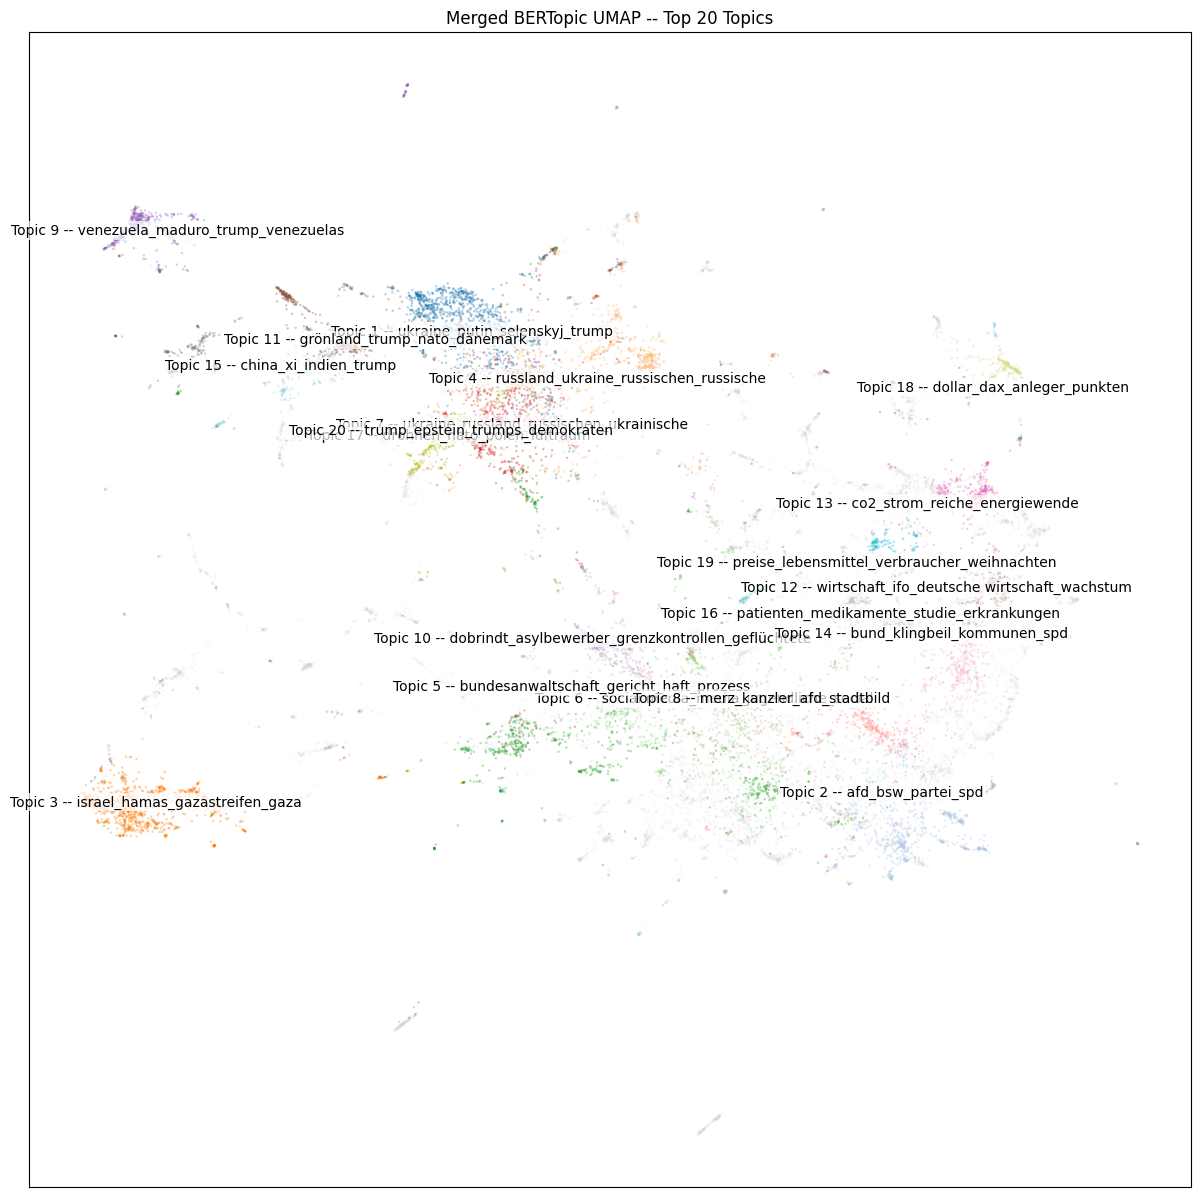

In [7]:
from merged_outlets_analysis import plot_merged_topic_umap, THESIS_COLORS

fig, ax = plot_merged_topic_umap(merged_articles, merged_topic_info, top_n=20)
fig.savefig(OUTPUT_DIR / ITERATION_ID / "umap_global.pdf", bbox_inches="tight", dpi=300)
plt.show()

## Semantic Footprint Maps

One per outlet — shows where each outlet's articles cluster in the merged topic space.

In [ ]:
import matplotlib.pyplot as plt
from visualization import plot_all_outlet_umaps

figs = plot_all_outlet_umaps(
    merged_articles,
    merged_topic_info,
    save_dir=OUTPUT_DIR / ITERATION_ID / "footprints",
)
for fig in figs:
    plt.show()
    plt.close(fig)

## Decision Point

**Check before proceeding to notebook 02:**

- [ ] Top topics are semantically coherent (not noise/garbage)
- [ ] Outlier rates are comparable across outlets (< 15% difference)
- [ ] Topic count is reasonable (not too few, not fragmented)
- [ ] UMAP shows identifiable clusters, not a uniform blob

If any check fails → change parameters above and re-run.

If all pass → proceed to `02_h1_results.ipynb`.